# Scarf Detection

## Import Libraries

In [1]:
# General libraries for data manipulation and file handling
import os
import numpy as np
import pandas as pd

# Libraries for image processing
import cv2
from PIL import Image

# Libraries for building and training the deep learning model
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

# Libraries for model evaluation
from sklearn.metrics import classification_report, confusion_matrix

2025-09-12 21:02:28.149277: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1757710948.391323      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1757710948.462636      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


## Load Dataset

In [2]:
import os

# List everything in the dataset directory
for dirname, _, filenames in os.walk('/kaggle/input/'):
    print(dirname)

/kaggle/input/
/kaggle/input/scarf-detection-dataset
/kaggle/input/scarf-detection-dataset/Scarf Detection Dataset
/kaggle/input/scarf-detection-dataset/Scarf Detection Dataset/Valid
/kaggle/input/scarf-detection-dataset/Scarf Detection Dataset/Valid/Without Scarf
/kaggle/input/scarf-detection-dataset/Scarf Detection Dataset/Valid/With Scarf
/kaggle/input/scarf-detection-dataset/Scarf Detection Dataset/Test
/kaggle/input/scarf-detection-dataset/Scarf Detection Dataset/Test/Without Scarf
/kaggle/input/scarf-detection-dataset/Scarf Detection Dataset/Test/With Scarf
/kaggle/input/scarf-detection-dataset/Scarf Detection Dataset/Train
/kaggle/input/scarf-detection-dataset/Scarf Detection Dataset/Train/Without Scarf
/kaggle/input/scarf-detection-dataset/Scarf Detection Dataset/Train/With Scarf


## Preprocess Data

In [3]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Image size and batch size
IMG_HEIGHT, IMG_WIDTH = 224, 224
BATCH_SIZE = 32

# Training data generator with augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Validation data generator (only rescaling)
valid_datagen = ImageDataGenerator(
    rescale=1./255
)

# Test data generator (only rescaling)
test_datagen = ImageDataGenerator(
    rescale=1./255
)

# Paths
TRAIN_DIR = "/kaggle/input/scarf-detection-dataset/Scarf Detection Dataset/Train"
VALID_DIR = "/kaggle/input/scarf-detection-dataset/Scarf Detection Dataset/Valid"
TEST_DIR  = "/kaggle/input/scarf-detection-dataset/Scarf Detection Dataset/Test"

# Load datasets
train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

valid_generator = valid_datagen.flow_from_directory(
    VALID_DIR,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)


Found 1259 images belonging to 2 classes.
Found 270 images belonging to 2 classes.
Found 270 images belonging to 2 classes.


## Model MobileNetV2

In [4]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Input

# Load MobileNetV2 base model (pretrained on ImageNet)
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(IMG_HEIGHT, IMG_WIDTH, 3))

# Freeze the base model layers to retain pretrained features
base_model.trainable = False

# Add custom layers on top
inputs = Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3))
x = base_model(inputs, training=False)
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)  # optional dropout for regularization
outputs = Dense(1, activation='sigmoid')(x)  # binary classification

model = Model(inputs, outputs)

# Compile the model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Print model summary
model.summary()


I0000 00:00:1757710964.381246      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1757710964.381967      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## Training Model

In [5]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

# Unfreeze the top layers of MobileNetV2 for fine-tuning
base_model.trainable = True

# Freeze first N layers to retain low-level features (experiment with N)
for layer in base_model.layers[:100]:  # freeze first 100 layers
    layer.trainable = False

# Compile the model with a lower learning rate for fine-tuning
model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Callbacks
checkpoint = ModelCheckpoint(
    'best_scarf_model.h5',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

earlystop = EarlyStopping(
    monitor='val_accuracy',
    patience=7,
    verbose=1,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    verbose=1,
    min_lr=1e-6
)

callbacks_list = [checkpoint, earlystop, reduce_lr]

# Train the model
EPOCHS = 20  # increase epochs for better fine-tuning

history = model.fit(
    train_generator,
    validation_data=valid_generator,
    epochs=EPOCHS,
    callbacks=callbacks_list
)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20


I0000 00:00:1757710985.005165      83 service.cc:148] XLA service 0x7d4744003080 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1757710985.006275      83 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1757710985.006297      83 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1757710986.918837      83 cuda_dnn.cc:529] Loaded cuDNN version 90300


 1/40 ━━━━━━━━━━━━━━━━━━━━ 17:24 27s/step - accuracy: 0.2727 - loss: 0.9878

I0000 00:00:1757710995.039101      83 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 781ms/step - accuracy: 0.5801 - loss: 0.7015
Epoch 1: val_accuracy improved from -inf to 0.59630, saving model to best_scarf_model.h5
40/40 ━━━━━━━━━━━━━━━━━━━━ 68s 1s/step - accuracy: 0.5827 - loss: 0.6987 - val_accuracy: 0.5963 - val_loss: 0.6005 - learning_rate: 1.0000e-05
Epoch 2/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 448ms/step - accuracy: 0.8672 - loss: 0.3482
Epoch 2: val_accuracy improved from 0.59630 to 0.67407, saving model to best_scarf_model.h5
40/40 ━━━━━━━━━━━━━━━━━━━━ 20s 510ms/step - accuracy: 0.8676 - loss: 0.3473 - val_accuracy: 0.6741 - val_loss: 0.4982 - learning_rate: 1.0000e-05
Epoch 3/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 440ms/step - accuracy: 0.9422 - loss: 0.2179
Epoch 3: val_accuracy improved from 0.67407 to 0.73704, saving model to best_scarf_model.h5
40/40 ━━━━━━━━━━━━━━━━━━━━ 20s 504ms/step - accuracy: 0.9425 - loss: 0.2173 - val_accuracy: 0.7370 - val_loss: 0.4262 - learning_rate: 1.0000e-05
Epoch 4/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 449m

## Evaluate on Test Data

In [6]:
# Load the best saved model
from tensorflow.keras.models import load_model
best_model = load_model('best_scarf_model.h5')

# Evaluate on test set
test_loss, test_accuracy = best_model.evaluate(test_generator)
print(f"Test Accuracy: {test_accuracy*100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

# Confusion Matrix and Classification Report
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

# Get true labels and predictions
test_generator.reset()
y_true = test_generator.classes
y_pred_prob = best_model.predict(test_generator)
y_pred = (y_pred_prob > 0.5).astype(int).reshape(-1)

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:\n", cm)

# Classification report
report = classification_report(y_true, y_pred, target_names=test_generator.class_indices.keys())
print("Classification Report:\n", report)


# Step 6b: Real-time prediction function for uploaded images
def predict_scarf(image_path):
    """
    Input: Path to image
    Output: Print whether image has scarf or not
    """
    img = Image.open(image_path).convert('RGB')
    img = img.resize((IMG_HEIGHT, IMG_WIDTH))
    img_array = np.array(img)/255.0
    img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension
    
    prediction_prob = best_model.predict(img_array)[0][0]
    if prediction_prob > 0.5:
        print("This is a scarf image.")
    else:
        print("This image does not contain a scarf.")

9/9 ━━━━━━━━━━━━━━━━━━━━ 7s 403ms/step - accuracy: 0.9733 - loss: 0.0749
Test Accuracy: 97.41%
Test Loss: 0.0672
9/9 ━━━━━━━━━━━━━━━━━━━━ 8s 541ms/step
Confusion Matrix:
 [[131   4]
 [  3 132]]
Classification Report:
                precision    recall  f1-score   support

   With Scarf       0.98      0.97      0.97       135
Without Scarf       0.97      0.98      0.97       135

     accuracy                           0.97       270
    macro avg       0.97      0.97      0.97       270
 weighted avg       0.97      0.97      0.97       270



## Testing Model

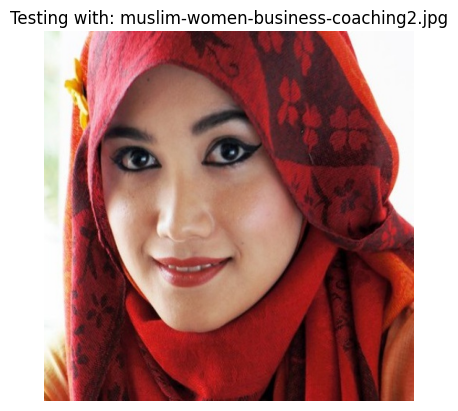


Testing prediction function with a local image...
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
Prediction: This is a scarf image. (Prob: 0.01)


In [7]:
import os
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model

# Load model
try:
    best_model = load_model('/kaggle/working/best_scarf_model.h5')
except OSError:
    print("Error: 'best_scarf_model.h5' not found. Make sure you have trained the model and the file exists.")
    exit() # Agar model nahi mila to code band kar de

# path of test folder
test_folder = "/kaggle/input/scarf-detection-dataset/Scarf Detection Dataset/Test/With Scarf"

# Folder mein mojood saari images ki list banaye
image_files = os.listdir(test_folder)

# List mein se pehli image ko uthaye
if len(image_files) > 0:
    first_image_name = image_files[0]
    test_image_path = os.path.join(test_folder, first_image_name)

    # Image ko load karein
    try:
        test_image = Image.open(test_image_path)
    except Exception as e:
        print(f"Error loading image: {e}")
        exit()

    # Image ko display karein
    plt.imshow(test_image)
    plt.title(f"Testing with: {first_image_name}")
    plt.axis('off')
    plt.show()

    # Prediction function ko call karein
    def predict_local_image(img):
        IMG_HEIGHT, IMG_WIDTH = 224, 224 # Same as training
        img_resized = img.resize((IMG_HEIGHT, IMG_WIDTH))
        img_array = np.array(img_resized) / 255.0
        img_array = np.expand_dims(img_array, axis=0)
        
        prediction_prob = best_model.predict(img_array)[0][0]
        
        # Naya Sahi Code with Correct Indentation:
        if prediction_prob > 0.5:
            print(f"Prediction: This image does NOT contain a scarf. (Prob: {prediction_prob:.2f})")
        else:
            print(f"Prediction: This is a scarf image. (Prob: {prediction_prob:.2f})")
    
    print("\nTesting prediction function with a local image...")
    predict_local_image(test_image)

else:
    print(f"Error: {test_folder} folder is empty.")

## Upload Image

In [8]:
# Imports
from ipywidgets import FileUpload, VBox
from IPython.display import display, clear_output
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import io

# Assuming best_model is your trained MobileNetV2 model
# and IMG_HEIGHT, IMG_WIDTH are defined

# Upload widget
upload_widget = FileUpload(
    accept='image/*',
    multiple=False
)

display(VBox([upload_widget]))

# Function to predict on uploaded image
def predict_uploaded_image(file_info):
    # Read image from uploaded file
    img = Image.open(io.BytesIO(file_info['content'])).convert('RGB')
    
    # Clear output and display the uploaded image
    clear_output(wait=True)
    plt.figure(figsize=(4,4))
    plt.imshow(img)
    plt.title(f"Uploaded Image")
    plt.axis('off')
    plt.show()
    
    # Preprocess image
    img_resized = img.resize((IMG_HEIGHT, IMG_WIDTH))
    img_array = np.array(img_resized) / 255.0
    img_array = np.expand_dims(img_array, axis=0)
    
    # Make prediction
    prediction_prob = best_model.predict(img_array)[0][0]
    
    # Print result with correct logic
    if prediction_prob > 0.5:
        # 0.5+ means "Without Scarf" (depending on your class ordering)
        print(f"Prediction: This image does NOT contain a scarf. (Confidence: {prediction_prob:.2f})")
    else:
        # Less than 0.5 means "With Scarf"
        print(f"Prediction: This is a scarf image. (Confidence: {1 - prediction_prob:.2f})")

# Function to handle uploaded file
def on_upload_change(change):
    if len(upload_widget.value) == 0:
        return
    for uploaded_filename, file_info in upload_widget.value.items():
        predict_uploaded_image(file_info)

# Connect callback
upload_widget.observe(on_upload_change, names='value')


## Summary 
This project focuses on scarf detection using MobileNetV2 in computer vision. The pretrained MobileNetV2 acts as a feature extractor, with custom layers added for binary classification to detect scarves in images. Dropout is used for regularization, enabling accurate and efficient detection suitable for real-time applications.